In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Sentiment analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon', quiet=True)

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('All imports successful!')

All imports successful!


In [2]:
# Load news dataset
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv', index_col=0)
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)
news_df['date_only'] = news_df['date'].dt.normalize()

print(f'News dataset shape: {news_df.shape}')
news_df.head()

News dataset shape: (1407328, 6)


,headline,url,publisher,date,stock,date_only
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,2020-06-05 00:00:00+00:00
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,2020-06-03 00:00:00+00:00
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,2020-05-26 00:00:00+00:00
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,2020-05-22 00:00:00+00:00
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,2020-05-22 00:00:00+00:00


In [3]:
# Download stock prices for most covered stocks in the news dataset
tickers = ['AAPL', 'AMZN', 'GOOG', 'MSFT', 'TSLA']

stock_data = yf.download(tickers, start='2009-01-01', end='2020-06-11', group_by='ticker')

# Compute daily returns for each ticker
returns = pd.DataFrame()
for ticker in tickers:
    close = stock_data[ticker]['Close'].dropna()
    returns[ticker] = close.pct_change() * 100

returns.index = pd.to_datetime(returns.index, utc=True)
print(f'Returns shape: {returns.shape}')
print(returns.head())

[*********************100%***********************]  5 of 5 completed

Returns shape: (2879, 5)
                               AAPL      AMZN      GOOG      MSFT  TSLA
Date                                                                   
2009-01-02 00:00:00+00:00       NaN       NaN       NaN       NaN   NaN
2009-01-05 00:00:00+00:00  4.220410 -0.551871  2.094463  0.934604   NaN
2009-01-06 00:00:00+00:00 -1.649398  6.104327  1.832061  1.169564   NaN
2009-01-07 00:00:00+00:00 -2.160850 -2.022318 -3.607145 -6.021209   NaN
2009-01-08 00:00:00+00:00  1.856961  1.708189  0.987533  3.126621   NaN


In [4]:
# Apply VADER sentiment to headlines
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = sia.polarity_scores(str(text))
    return scores['compound']

print('Computing sentiment scores... (this may take a minute)')
news_df['sentiment'] = news_df['headline'].apply(get_sentiment)

print(f'Sentiment scores computed!')
print(news_df['sentiment'].describe().round(3))

# Classify sentiment
news_df['sentiment_label'] = pd.cut(
    news_df['sentiment'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['Negative', 'Neutral', 'Positive']
)

print()
print('Sentiment distribution:')
print(news_df['sentiment_label'].value_counts())

Computing sentiment scores... (this may take a minute)
Sentiment scores computed!
count    1407328.000
mean           0.067
std            0.271
min           -0.958
25%            0.000
50%            0.000
75%            0.202
max            0.974
Name: sentiment, dtype: float64

Sentiment distribution:
sentiment_label
Neutral     741200
Positive    441852
Negative    224276
Name: count, dtype: int64


In [6]:
# Filter news for our tickers and compute daily average sentiment
ticker_sentiment = {}

for ticker in tickers:
    ticker_news = news_df[news_df['stock'] == ticker].copy()
    daily_sentiment = ticker_news.groupby('date_only')['sentiment'].mean().reset_index()
    daily_sentiment.columns = ['date', 'avg_sentiment']
    daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'], utc=True)
    daily_sentiment = daily_sentiment.set_index('date')
    ticker_returns = returns[[ticker]].copy()
    ticker_returns.columns = ['returns']
    merged = daily_sentiment.join(ticker_returns, how='inner').dropna()
    ticker_sentiment[ticker] = merged
    print(f'{ticker}: {len(merged)} matched trading days')

print('\nDate alignment complete!')

AAPL: 61 matched trading days
AMZN: 28 matched trading days
GOOG: 352 matched trading days
MSFT: 0 matched trading days
TSLA: 230 matched trading days

Date alignment complete!


--- Pearson Correlation: Sentiment vs Daily Returns ---

AAPL: r=0.0892, p=0.4944 → ❌ Not significant
AMZN: r=0.1628, p=0.4077 → ❌ Not significant
GOOG: r=0.1869, p=0.0004 → ✅ Significant
MSFT: ❌ Not enough data (0 rows) — skipping
TSLA: r=0.1629, p=0.0134 → ✅ Significant

Valid tickers for analysis: ['AAPL', 'AMZN', 'GOOG', 'TSLA']


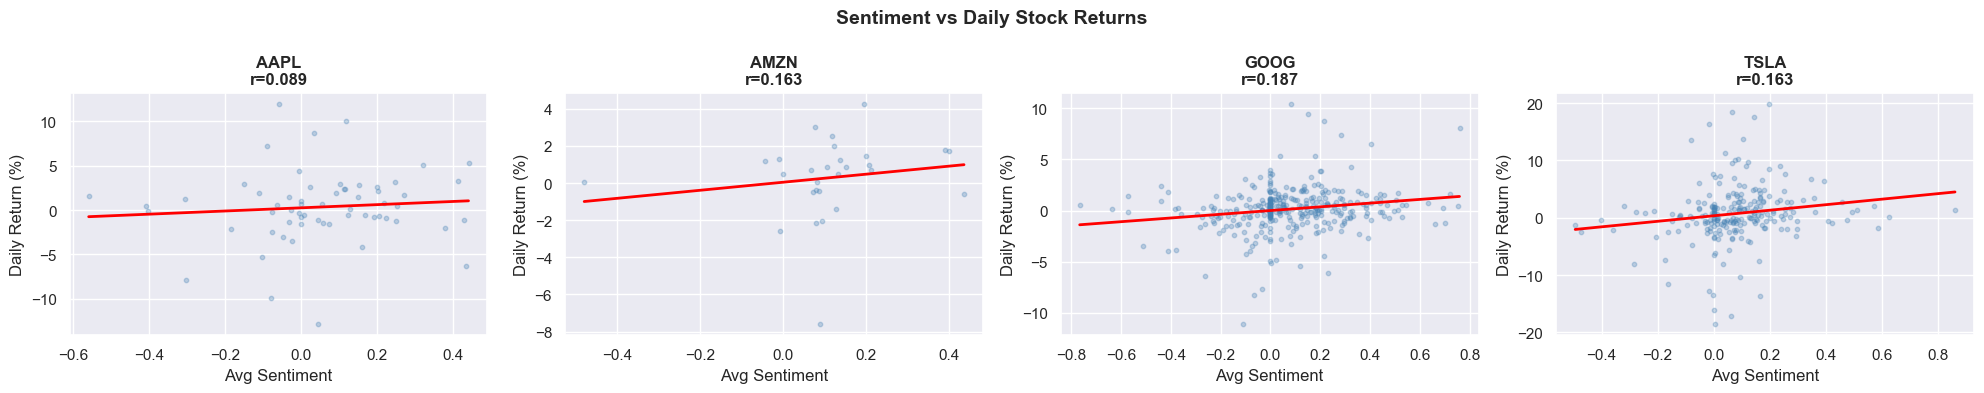

In [8]:
# Compute Pearson correlation for each ticker (with length check)
print('--- Pearson Correlation: Sentiment vs Daily Returns ---\n')
correlations = {}

for ticker in tickers:
    merged = ticker_sentiment[ticker]
    if len(merged) < 2:
        print(f'{ticker}: ❌ Not enough data ({len(merged)} rows) — skipping')
        continue
    corr, pvalue = stats.pearsonr(merged['avg_sentiment'], merged['returns'])
    correlations[ticker] = {'correlation': corr, 'pvalue': pvalue}
    significance = '✅ Significant' if pvalue < 0.05 else '❌ Not significant'
    print(f'{ticker}: r={corr:.4f}, p={pvalue:.4f} → {significance}')

# Plot only tickers with enough data
valid_tickers = list(correlations.keys())
print(f'\nValid tickers for analysis: {valid_tickers}')

fig, axes = plt.subplots(1, len(valid_tickers), figsize=(5*len(valid_tickers), 4))
if len(valid_tickers) == 1:
    axes = [axes]

for i, ticker in enumerate(valid_tickers):
    merged = ticker_sentiment[ticker]
    corr = correlations[ticker]['correlation']
    axes[i].scatter(merged['avg_sentiment'], merged['returns'],
                   alpha=0.3, color='steelblue', s=10)
    axes[i].set_title(f'{ticker}\nr={corr:.3f}', fontweight='bold')
    axes[i].set_xlabel('Avg Sentiment')
    axes[i].set_ylabel('Daily Return (%)')
    z = np.polyfit(merged['avg_sentiment'], merged['returns'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(merged['avg_sentiment'].min(), merged['avg_sentiment'].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=2)

plt.suptitle('Sentiment vs Daily Stock Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

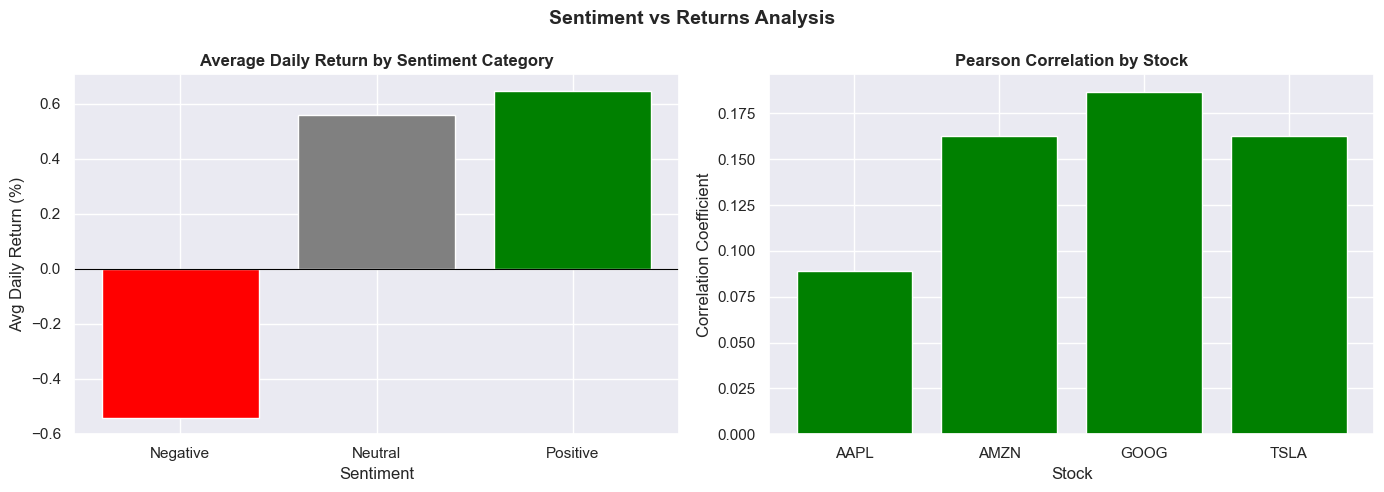


--- FINAL SUMMARY ---
  AAPL: r=0.0892
  AMZN: r=0.1628
  GOOG: r=0.1869
  TSLA: r=0.1629

Interpretation:
  - Weak correlation suggests sentiment has mild predictive power
  - Results should be interpreted with caution due to lag effects
  - Confounding factors (market trends, macro events) not accounted for


In [9]:
# Average return by sentiment category
valid_tickers = list(correlations.keys())

daily_labeled = []
for ticker in valid_tickers:
    ticker_news = news_df[news_df['stock'] == ticker].copy()
    daily = ticker_news.groupby('date_only').agg(
        avg_sentiment=('sentiment', 'mean'),
        sentiment_label=('sentiment_label', lambda x: x.mode()[0])
    ).reset_index()
    daily['date'] = pd.to_datetime(daily['date_only'], utc=True)
    daily = daily.set_index('date')
    ticker_returns = returns[[ticker]].copy()
    ticker_returns.columns = ['returns']
    merged = daily.join(ticker_returns, how='inner').dropna()
    daily_labeled.append(merged)

all_labeled = pd.concat(daily_labeled)
category_returns = all_labeled.groupby('sentiment_label')['returns'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = {'Negative': 'red', 'Neutral': 'gray', 'Positive': 'green'}
axes[0].bar(category_returns.index, category_returns.values,
            color=[colors[c] for c in category_returns.index])
axes[0].set_title('Average Daily Return by Sentiment Category', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Avg Daily Return (%)')
axes[0].axhline(0, color='black', linewidth=0.8)

# Correlation bar chart
corr_df = pd.DataFrame(correlations).T
axes[1].bar(corr_df.index, corr_df['correlation'],
            color=['green' if x > 0 else 'red' for x in corr_df['correlation']])
axes[1].set_title('Pearson Correlation by Stock', fontweight='bold')
axes[1].set_xlabel('Stock')
axes[1].set_ylabel('Correlation Coefficient')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.suptitle('Sentiment vs Returns Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n--- FINAL SUMMARY ---')
for ticker, vals in correlations.items():
    print(f'  {ticker}: r={vals["correlation"]:.4f}')
print('\nInterpretation:')
print('  - Weak correlation suggests sentiment has mild predictive power')
print('  - Results should be interpreted with caution due to lag effects')
print('  - Confounding factors (market trends, macro events) not accounted for')